# Rice Grain Image Classification With YOLOv8

Author: **Marcin Sikorski**<br>
Date: March, 2026

**Motivation**

To develop this notebook we used the open dataset available on [Kaggle](https://www.kaggle.com/datasets/muratkokludataset/rice-image-dataset). It contains 75k images including 15k images for each of the five rice variety. The dataset was used to solve a classification problem. We want to develop a pretrained YOLO model to correctly classify five types of rice grains.

Although YOLO is widely known for object detection, YOLOv8 provides a dedicated classification variant (`yolov8n-cls`) that:
* is lightweight and optimized for speed;
* supports transfer learning from pre-trained weights;
* includes built-in augmentation and training utilities;
* provides streamlined training and inference APIs;
* easy to initialize and tune.

**Why Not ResNet / EfficientNet?**

ResNet and EfficientNet are strong baselines for image classification, but YOLOv8 was selected for:
* faster experimentation workflow;
* simpler training pipeline;
* better integration with detection tasks (future extensibility);
* efficient performance on limited hardware (e.g., free Google Colab, during training YOLO used max ~3.6 GB RAM).

**Notebook Content:**
1. Move ZIP to Fast SSD and Unzip
2. Dataset Review
3. Fast Dataset Split
4. Run YOLOv8
5. YOLOv8 Evaluation and Discussion
6. Grad-CAM
7. Conclusions

### 1. Move ZIP to Fast SSD and Unzip

The dataset is distributed in a ZIP file. To maximize speed, we will unzip it temporary at local SSD.

In [ ]:
# mount G-Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# copy zip file from G-Drive → fast local SSD
!cp /content/drive/MyDrive/rice-image-dataset.zip /content/

# unzip quietly
!unzip -q /content/rice-image-dataset.zip -d /content/

print('Dataset ready in /content')

Dataset ready in /content


### 2. Dataset Review

To review the dataset, image metadata such as height, width, and color mode are extracted and stored in a dataframe for analysis. The class label distribution is examined to detect potential imbalance among categories. Additionally, a sample of images from each class will be displayed to assess image quality and better understand the visual characteristics of the different rice varieties.

In [ ]:
import pandas as pd
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

# path to extracted dataset folder
dataset_path = '/content/Rice_Image_Dataset'

data = []

# walk through extracted directories
for root, dirs, files in os.walk(dataset_path):
    for filename in files:

        # only raster formats
        if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):

            full_path = os.path.join(root, filename)

            # label = parent folder name
            label = os.path.basename(root)

            # file extension
            extension = os.path.splitext(filename)[1]

            # size in KB
            size_kb = os.path.getsize(full_path) / 1024

            # open image normally (already extracted)
            with Image.open(full_path) as img:
                width, height = img.size
                mode = img.mode

            data.append({
                'image_path': full_path,
                'image_height': height,
                'image_width': width,
                'image_label': label,
                'image_extension': extension,
                'image_mode': mode,
                'image_size_kb': round(size_kb, 2),
            })

df = pd.DataFrame(data)
df.sample(n=5)

,image_path,image_height,image_width,image_label,image_extension,image_mode,image_size_kb
32324,/content/Rice_Image_Dataset/Arborio/Arborio (1...,250,250,Arborio,.jpg,RGB,3.41
60325,/content/Rice_Image_Dataset/Ipsala/Ipsala (358...,250,250,Ipsala,.jpg,RGB,3.51
74438,/content/Rice_Image_Dataset/Ipsala/Ipsala (391...,250,250,Ipsala,.jpg,RGB,3.99
55488,/content/Rice_Image_Dataset/Karacadag/Karacada...,250,250,Karacadag,.jpg,RGB,3.06
54805,/content/Rice_Image_Dataset/Karacadag/Karacada...,250,250,Karacadag,.jpg,RGB,3.02


In [ ]:
# descriptive statistics
df.describe()

,image_height,image_width,image_size_kb
count,75000.0,75000.0,75000.000000
mean,250.0,250.0,3.481106
std,0.0,0.0,0.380209
min,250.0,250.0,2.720000
25%,250.0,250.0,3.140000
50%,250.0,250.0,3.420000
75%,250.0,250.0,3.810000
max,250.0,250.0,4.570000


In [ ]:
# image extension & mode
print(df['image_extension'].unique())
print(df['image_mode'].unique())

['.jpg']
['RGB']


All images are perfectly unified in terms of pixel height, pixel width, file extension, and color mode.

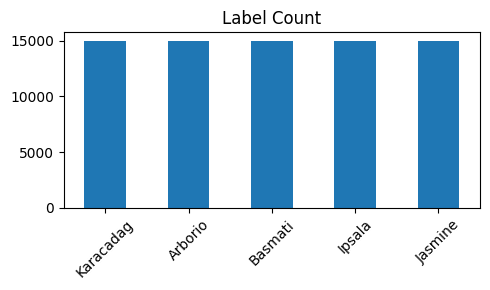

In [ ]:
plt.figure(figsize=(5, 3))

# count images per label
df['image_label'].value_counts().plot(kind='bar')

plt.title('Label Count')
plt.xlabel(None)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The rice classes are perfectly balanced, meaning each class has an equal number of samples. Therefore, accuracy is an appropriate primary evaluation metric since no class imbalance bias exists. No resampling or class weighting will be needed. However, this does not guarantee:
* the problem is easy;
* the model will perform equally well on all classes;
* no confusion between similar classes.

For example, two rice types might look visually similar but confusion matrix may still show misclassification.

In [ ]:
# label counts
df['image_label'].value_counts()

,count
image_label,
Karacadag,15000
Arborio,15000
Basmati,15000
Ipsala,15000
Jasmine,15000


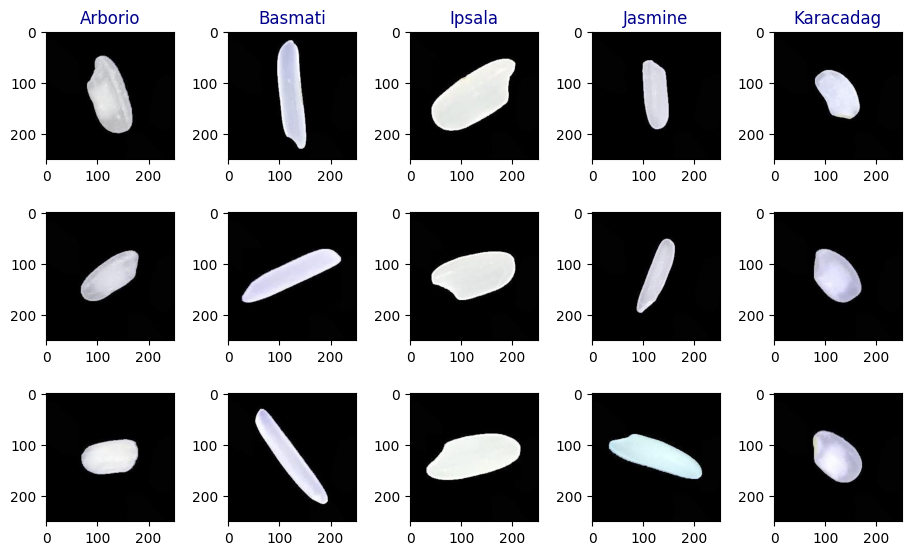

In [ ]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(9, 5.5), constrained_layout=True)
gs = GridSpec(3, 5, figure=fig, wspace=0.1, hspace=0.1)

for col_idx, category in enumerate(sorted(df['image_label'].unique())):

    class_images = df[df['image_label'] == category].head(3)

    for row_idx, row in enumerate(class_images.itertuples()):
        ax = fig.add_subplot(gs[row_idx, col_idx])

        # read directly from disk (NOT zip)
        img = Image.open(row.image_path).convert('RGB')

        ax.imshow(img)
        #plt.axis('off')

        # set class titles only on top row
        if row_idx == 0:
            ax.set_title(category, color='darkblue')

plt.show()

We can notice that rice varieties are distinguished by physical (morphological) characteristics. Each rice variety has special grain shape. Classifiers should focus on physical and visual appearance. The backgrounds are clear black and have no noise. The grains in the images are very uniformed.

For example, Basmati rice tends to be long-grain (slender and elongated), while Karacadag is more short-grain (round and fat). Ipsala appears to be much thicker. Other key features that distinguish rice varieties:
* **shape/aspect ratio:** the ratio of length to width (elongation) to determine the grain's slender or plump nature;
* **uniformity:** the consistency in shape and size within a sample;
* **surface texture:** the smoothness or roughness of the grain;
* **translucency/opacity:** whether the grain is clear or opaque indicates its internal structure.

### 3. Fast Dataset Split

YOLO classification expects a specific folder structure. Currently, the dataset is structured:
```
dataset/
├── class0/
├── class1/
├── class2/
├── class3/
└── class4/
```
But YOLOv8 classification expects this:
```
dataset/
│
├── train/
│   ├── class0/
│   ├── class1/
│   ├── class2/
│   ├── class3/
│   └── class4/
│
├── val/
│   ├── class0/
│   ├── class1/
│   ├── class2/
│   ├── class3/
│   └── class4/
│
└── test/
    ├── class0/
    ├── class1/
    ├── class2/
    ├── class3/
    └── class4/
```
The transformed dataset will be stored temporary in `/content`. We also want to keep class balance and split dataset into subsets:
* train 70%,
* validation 20%,
* test 10%.

In [ ]:
import random
import shutil
from pathlib import Path

# define paths
original_dataset = Path('/content/Rice_Image_Dataset')
output_dataset   = Path('/content/rice_yolo')

# split ratios
train_ratio = 0.7
val_ratio   = 0.2
test_ratio  = 0.1

# add random seed: make split reproducible
random.seed(42)

# create split directories
classes = [d for d in original_dataset.iterdir() if d.is_dir()]

for split in ['train', 'val', 'test']:
    for cls in classes:
        (output_dataset / split / cls.name).mkdir(parents=True, exist_ok=True)

# split images
for cls in classes:
    images = list(cls.glob('*.*'))
    random.shuffle(images)

    total = len(images)
    train_end = int(total * train_ratio)
    val_end = train_end + int(total * val_ratio)

    splits = {
        'train': images[:train_end],
        'val':   images[train_end:val_end],
        'test':  images[val_end:]
    }

    for split_name, split_images in splits.items():
        for img in split_images:
            shutil.move(str(img), output_dataset / split_name / cls.name / img.name)

print(f"Train size: {len(splits['train'])}")
print(f"Val size:   {len(splits['val'])}")
print(f"Test size:  {len(splits['test'])}")

Train size: 10500
Val size:   3000
Test size:  1500


### 4. Run YOLOv8

YOLO models are distributed by Ultralytics through the `ultralytics` Python module. In this project, we will use the pre-trained YOLOv8 nano model, which is a lightweight architecture suitable for efficient training.

The classifier will be trained in two stages:
* **first run:** 14 epochs with a learning rate of 0.01;
* **second run:** training is continued from the previously saved weights for 6 additional epochs with a reduced learning rate of 0.0001.

Both training sessions use the AdamW optimizer, which improves convergence speed and model performance. AdamW introduces weight regularization through weight decay, which generally leads to better generalization.

In [ ]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# initialize pretrained YOLOv8 classification model
model = YOLO('yolov8n-cls.pt')  # nano model (smallest, fastest)

# create folder to store run results
project_path = '/content/drive/MyDrive/yolo_runs'

# train model
model.train(
    data='/content/rice_yolo',
    epochs=14,
    imgsz=224,
    batch=32,
    optimizer='AdamW',
    name='rice_classification',
    project=project_path,    # save to drive
    save=True,
    verbose=True,
    workers=2,               # Colab CPU threads
    save_period=1,           # save checkpoint every epoch

    # optional image augmentation
    #flipud=0.5,
    #fliplr=0.5,
    #hsv_h=0.015,
    #hsv_s=0.7,
    #hsv_v=0.4,
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rice_yolo, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=14, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, i

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cd8a074fd70>
curves: []
curves_results: []
fitness: 0.9991666674613953
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9983333349227905, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9991666674613953}
save_dir: PosixPath('/content/drive/MyDrive/yolo_runs/rice_classification')
speed: {'preprocess': 0.0004969276027016651, 'inference': 10.81999531853556, 'loss': 2.363500437544038e-05, 'postprocess': 4.4806136672074595e-05}
task: 'classify'
top1: 0.9983333349227905
top5: 1.0

In [ ]:
from ultralytics import YOLO

# previous model (last weights)
model_path = '/content/drive/MyDrive/yolo_runs/rice_classification/weights/last.pt'
model = YOLO(model_path)

project_path = '/content/drive/MyDrive/yolo_runs'

# continue training from previous weights
model.train(
    data='/content/rice_yolo',
    epochs=6,                    # continue from epoch 15 → 20
    batch=32,
    imgsz=224,
    optimizer='AdamW',
    lr0=0.0001,                  # reduce lr 0.01 → 0.0001
    name='rice_classification_continue',
    project=project_path,
    save=True,
    verbose=True,
    workers=2,
    save_period=1,
    resume=False,
    )

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/rice_yolo, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=6, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, io

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x783913311910>
curves: []
curves_results: []
fitness: 0.9994666576385498
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.9989333152770996, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9994666576385498}
save_dir: PosixPath('/content/drive/MyDrive/yolo_runs/rice_classification_continue')
speed: {'preprocess': 0.0006116720678013129, 'inference': 14.6072605836666, 'loss': 2.868899925185057e-05, 'postprocess': 4.623920103767887e-05}
task: 'classify'
top1: 0.9989333152770996
top5: 1.0

### 5. YOLOv8 Evaluation and Discussion

We will evaluate the YOLO model's performance using several approaches, including analysis of learning curves, evaluation metrics, and the confusion matrix. Basic metrics such as precision, recall, accuracy, and confidence will be compared across classes.

The results will be examined to identify patterns, strengths, and weaknesses of the trained model.

In [ ]:
from ultralytics import YOLO

# load best model (latest run)
model_path = '/content/drive/MyDrive/yolo_runs/rice_classification_continue/weights/best.pt'
model = YOLO(model_path)

# validation YOLO on test data to get metrics (~2.5 min)
metrics = model.val(data='/content/rice_yolo', split='test', verbose=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,441,285 parameters, 0 gradients, 3.3 GFLOPs
train: /content/rice_yolo/train... found 52500 images in 5 classes ✅ 
val: /content/rice_yolo/val... found 15000 images in 5 classes ✅ 
test: /content/rice_yolo/test... found 7500 images in 5 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 67.8±31.6 MB/s, size: 3.5 KB)
test: Scanning /content/rice_yolo/test... 7500 images, 0 corrupt: 100% ━━━━━━━━━━━━ 7500/7500 3.8Kit/s 2.0s
test: New cache created: /content/rice_yolo/test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 469/469 

In [ ]:
# basic metrics
metrics.results_dict

{'metrics/accuracy_top1': 0.9989333152770996,
 'metrics/accuracy_top5': 1.0,
 'fitness': 0.9994666576385498}

* **Top-1 Accuracy:** the model predicted the correct class as its highest-confidence prediction 99.83% of the time. Only ~0.17% of samples were misclassified at rank 1.
* **Top-5 Accuracy:** the correct class was always within the model's top 5 predictions. The classifier never completely 'missed' the correct label — even when its first guess was wrong.
* **Fitness:** it is typically a weighted combination of evaluation metrics. Fitness near 1.0 indicates near-perfect validation performance and a very stable and well-optimized model.

In [ ]:
# load CSV files from both runs
run1_path = '/content/drive/MyDrive/yolo_runs/rice_classification/results.csv'
run2_path = '/content/drive/MyDrive/yolo_runs/rice_classification_continue/results.csv'

df1 = pd.read_csv(run1_path)
df2 = pd.read_csv(run2_path)

# shift second run epochs
df2['epoch'] = df2['epoch'] + df1['epoch'].max()

# concatenate into one continuous
merged_df = pd.concat([df1, df2], ignore_index=True)

merged_df.tail(n=5)

,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
15,16,6525.53,0.03995,0.99873,1,0.00403,0.000056,0.000056,0.033409
16,17,9807.11,0.03414,0.99873,1,0.00364,0.000067,0.000067,0.000087
17,18,13088.50,0.03006,0.99893,1,0.00337,0.000051,0.000051,0.000051
18,19,16356.30,0.02908,0.99893,1,0.00343,0.000034,0.000034,0.000034
19,20,19667.50,0.02925,0.99900,1,0.00343,0.000017,0.000017,0.000017


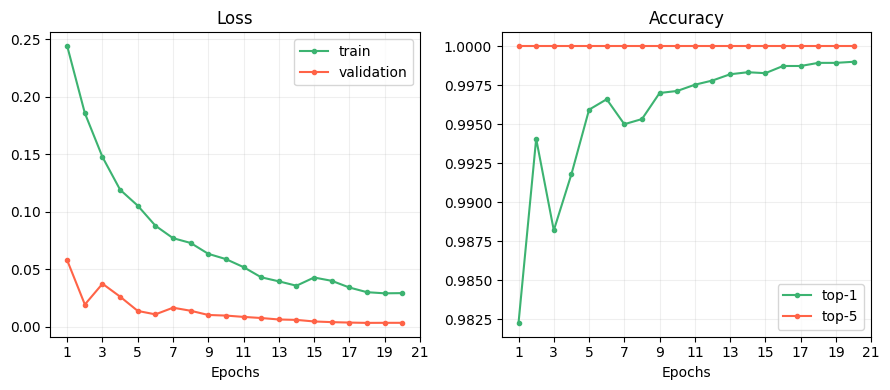

In [ ]:
# plot learning curves
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# line propeties
train_props = {'color': 'mediumseagreen', 'marker': '.'}
val_props   = {'color': 'tomato', 'marker': '.'}

# show every second epoch → 1, 3, ..., 19, 21
xticks = range(
    int(merged_df['epoch'].min()),
    int(merged_df['epoch'].max()) + 2,
    2,   # step size
)

# 1. loss plot
axes[0].plot(merged_df['epoch'], merged_df['train/loss'], label='train', **train_props)
axes[0].plot(merged_df['epoch'], merged_df['val/loss'], label='validation', **val_props)

axes[0].set_xlabel('Epochs')
axes[0].set_title('Loss')
axes[0].set_xticks(xticks)
axes[0].legend()
axes[0].grid(alpha=0.2)

# 2. accuracy plot
axes[1].plot(merged_df['epoch'], merged_df['metrics/accuracy_top1'], label='top-1', **train_props)
axes[1].plot(merged_df['epoch'], merged_df['metrics/accuracy_top5'], label='top-5', **val_props)

axes[1].set_xlabel('Epochs')
axes[1].set_title('Accuracy')
axes[1].set_xticks(xticks)
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

The learning curves indicate a correct and well-balanced training run. There are no visible data leakages or optimizer issues. Key characteristics include:
* clean and gradual convergence: training and validation curves track each other well after the initial warm-up;
* no serious overfitting: the gaps between the curves remains small and acceptable.

By examining the curves, the model appears to generalize very well, providing a solid and well-tuned baseline.

In [ ]:
class_names = [
    'Arborio',
    'Basmati',
    'Ipsala',
    'Jasmine',
    'Karacadag',
    ]

# extract confusion matrix
cm = metrics.confusion_matrix.matrix    # NumPy array
cm = cm[:-1, :-1]                       # remove background row & column
#cm = np.array(cm)
cm = cm.astype(int)                     # force integer formatting

# True Positives
TP = np.diag(cm)

# per-class accuracy = TP / total true samples per class
per_class_acc = TP / cm.sum(axis=1)

# False Positives
FP = cm.sum(axis=0) - TP

# False Negatives
FN = cm.sum(axis=1) - TP

# compute metrics
precision = TP / (TP + FP + 1e-9)
recall = TP / (TP + FN + 1e-9)
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

# display results
df_metrics = pd.DataFrame({
    'Class': class_names,
    'Accuracy': per_class_acc,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

df_metrics.style.hide()

Class,Accuracy,Precision,Recall,F1-Score
Arborio,0.999333,0.998667,0.999333,0.999000
Basmati,1.000000,0.996667,1.000000,0.998331
Ipsala,1.000000,1.000000,1.000000,1.000000
Jasmine,0.996016,1.000000,0.996016,0.998004
Karacadag,0.999333,0.999333,0.999333,0.999333


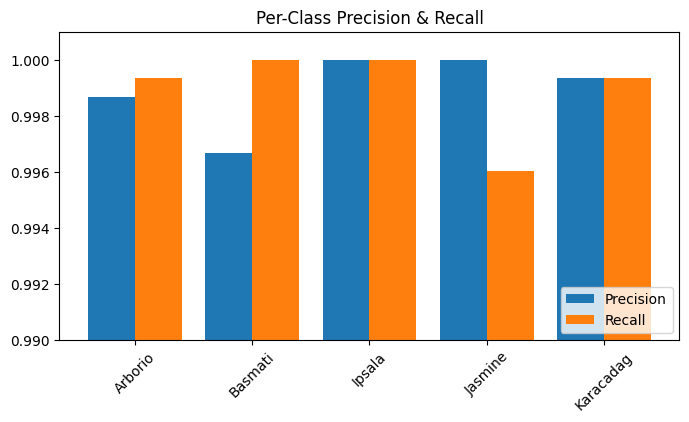

In [ ]:
x = np.arange(len(class_names))

# plot precisions & recalls
plt.figure(figsize=(8, 4))
plt.bar(x - 0.2, precision, width=0.4, label='Precision')
plt.bar(x + 0.2, recall, width=0.4, label='Recall')

plt.xticks(x, class_names, rotation=45)
plt.ylim(0.99, 1.001)
plt.title('Per-Class Precision & Recall')
plt.legend(loc='lower right')

plt.show()

* **Precision**: All classes have extremely high precision, indicating that when the model predicts a rice type, it is almost always correct. Notably, Ipsala and Jasmine achieve perfect precision (1.0), meaning there are essentially no false positives for these classes.

* **Recall**: Recall is also near perfect for all classes, meaning the model successfully identifies almost all actual instances of each rice type. Basmati and Ipsala reach perfect recall (1.0), indicating no false negatives for these classes.

Overall, the model demonstrates excellent classification capability, with both precision and recall very close to 1 across all classes, suggesting minimal misclassification and strong reliability in distinguishing rice varieties. Ipsala displays perfect performance, while Basmati is most likely confused with Jasmine.

In [ ]:
cm

array([[1498,    0,    0,    0,    1],
       [   0, 1495,    0,    0,    0],
       [   0,    0, 1500,    0,    0],
       [   1,    5,    0, 1500,    0],
       [   1,    0,    0,    0, 1499]])

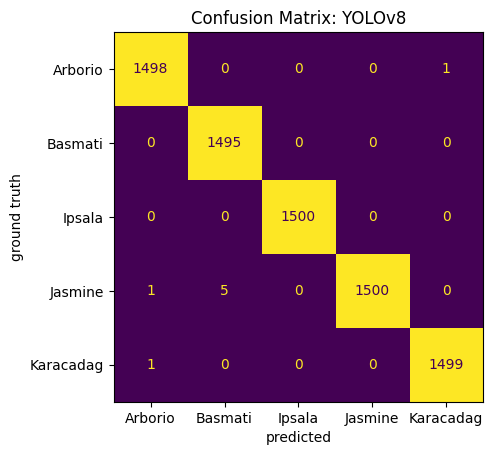

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# plot matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
    )

disp.plot(colorbar=None)
disp.ax_.set_title('Confusion Matrix: YOLOv8')
disp.ax_.set_xlabel('predicted')
disp.ax_.set_ylabel('ground truth')

plt.show()

Overall, this confusion matrix indicates:
* excellent generalization;
* very balanced performance;
* no systematic failure modes;
* predictions are strongly concentrated along the diagonal of the matrix;
* near-perfect separability in feature space;
* very strong visual separability between rice types;
* misclassifications are extremely rare (max 5 per class);
* the model learned highly discriminative features.
* no data leakage;
* no class dominance or collapse.

Two classes are perfectly classified: Basmati and Ipsala, with no misclassified samples. The highest misclassifications occurs between Jasmine and Basmati, where 5 Jasmine samples are predicted as Basmati. Minor errors are also observed where single samples of Arborio and Karacadag are misclassified as other varieties. Errors are likely due to visual similarity between those specific varieties (elongated grain morphology). In summary, the confusion matrix indicates very strong classification performance with only a few isolated errors.


In [ ]:
# accuracy based on CM
# accuracy = sum of diagonal / sum of all elements
accuracy = np.trace(cm) / np.sum(cm)

print(f'YOLOv8 accuracy: {accuracy:.4f}')

YOLOv8 accuracy: 0.9989


In [ ]:
import os

# test images
test_dir = '/content/rice_yolo/test'

results_data = []

# loop through test images for confidence scores (~3 min)
for class_id, class_name in enumerate(sorted(os.listdir(test_dir))):
    class_path = os.path.join(test_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        result = model(img_path, verbose=False)[0]

        probs = result.probs.data.cpu().numpy()
        pred_class = np.argmax(probs)
        confidence = np.max(probs)

        results_data.append([
            class_name,
            model.names[pred_class],
            confidence
        ])

# convert to dataframe
df_conf = pd.DataFrame(results_data, columns=['True_Class', 'Pred_Class', 'Confidence'])

# aggregate & get average conf per class
df_conf.groupby('True_Class')['Confidence'].mean()

,Confidence
True_Class,
Arborio,0.997890
Basmati,0.998151
Ipsala,0.999629
Jasmine,0.998756
Karacadag,0.999670


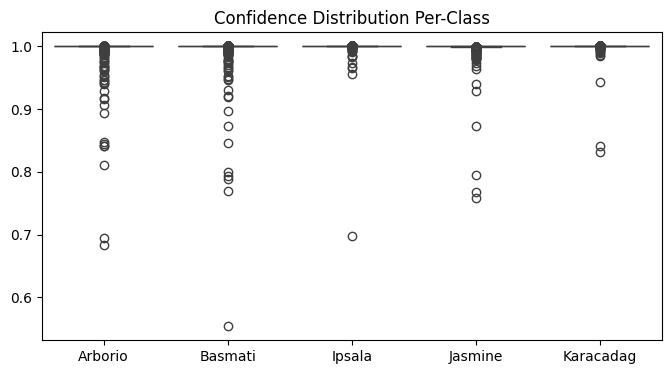

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_conf, x='True_Class', y='Confidence')
plt.title('Confidence Distribution Per-Class')
plt.xlabel(None)
plt.ylabel(None)

plt.show()

The classifier shows very high confidence across all rice classes, indicating that predictions are made with strong certainty. Karacadag and Ipsala have the highest confidence scores, suggesting these varieties are the most easily distinguishable by the model. Based on the larger marker spreads, Arborio and Basmati have slightly lower confidence compared to the others.

Overall, the confidence scores indicate that the model has excellent certainty and stability in its predictions, reinforcing the strong performance already observed in the previous metrics and confusion matrix.

In [ ]:
# display misclassified samples
df_misclass = df_conf[df_conf['True_Class'] != df_conf['Pred_Class']]
num_samples = len(df_misclass)

print(f'Total misclassified samples: {num_samples}\n')

df_misclass

Total misclassified samples: 8



,True_Class,Pred_Class,Confidence
1147,Arborio,Karacadag,0.841865
1281,Arborio,Jasmine,0.999830
1615,Basmati,Jasmine,0.769403
2043,Basmati,Jasmine,0.975471
2233,Basmati,Jasmine,0.967391
2341,Basmati,Jasmine,0.947824
2504,Basmati,Jasmine,0.799765
7398,Karacadag,Arborio,0.943662


This table shows the misclassified samples displayed previously in the confusion matrix.

### 6. Grad-CAM

Grad-CAM (gradient-weighted class activation mapping) is a technique for generating visual explanations of decisions made by a wide range of CNN-based models. It generates heatmaps indicating the most important areas of the input image, influencing the decision of the convolutional network. It is used to visualize the model's 'attention', increasing decision transparency, making it easier to debug dataset errors, and building confidence in deep learning systems. We will generate random Grad-CAMs for each class to visualize image captioning.

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=b10af6fc11e3b9fdfd874aada3325fa8bc3bd00a4174ac528f4be5c99c5c4d78
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


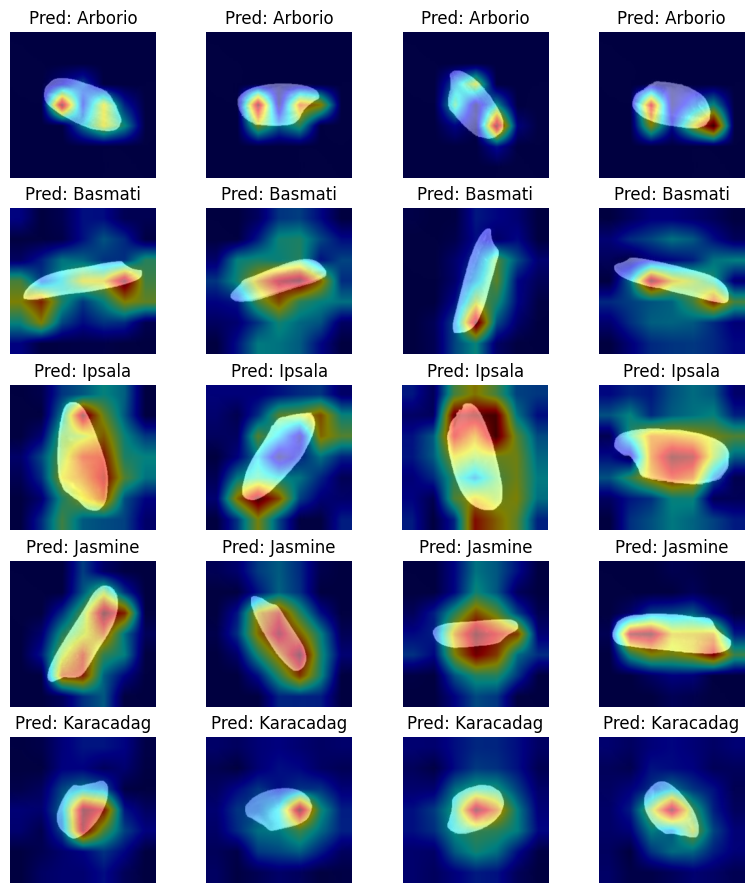

In [ ]:
import torch
from PIL import Image
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import random

# PyTorch network & eval mode
net = model.model
net.eval()

# test images
test_path = Path('/content/rice_yolo/test')

# very important: enable gradients
for param in net.parameters():
    param.requires_grad = True

# pick last convolution layer (for YOLOv8-cls)
target_layer = net.model[-2]

# classes
class_names = sorted(os.listdir(test_path))

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# create Grad-CAM
cam = GradCAM(model=net, target_layers=[target_layer])

fig, axes = plt.subplots(5, 4, figsize=(8, 9))
fig.subplots_adjust(wspace=0.5)

for row, class_name in enumerate(class_names):
    class_path = test_path / class_name
    image_paths = random.sample(list(class_path.glob('*.*')), 4)

    for col, img_path in enumerate(image_paths):
        img = Image.open(img_path).convert('RGB')
        input_tensor = transform(img).unsqueeze(0)

        # make sure input requires grad
        input_tensor.requires_grad = True

        # forward pass WITHOUT torch.no_grad()
        output = net(input_tensor)
        if isinstance(output, tuple):
            output = output[0]

        pred_class = output.softmax(dim=1).argmax(dim=1).item()
        pred_label = model.names[pred_class]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=[ClassifierOutputTarget(pred_class)],
            )[0]

        rgb_img = np.array(img.resize((224, 224))) / 255.0
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        axes[row, col].imshow(visualization)
        axes[row, col].axis('off')

        if col == 0:
            axes[row, col].set_ylabel(class_name, fontsize=12)

        axes[row, col].set_title(f'Pred: {pred_label}')

plt.tight_layout()
plt.show()

The highlighted regions often correspond to the grain edges and elongated central axis, which are key morphological features distinguishing rice varieties. This suggests that the model leverages shape-related information such as grain length and contour, which is what we should expect. The model primarily focuses on the rice grain itself rather than the surrounding background.

### 7. Conclusions

This notebook addressed the task of rice grain image classification using a transfer learning approach with a pre-trained YOLOv8 convolutional neural network (transfer learning). The classifier achieved strong performance, demonstrating high accuracy (~99%) and consistent predictions across the dataset. The few observed misclassifications were mainly due to visual similarities between certain classes, particularly Basmati and Jasmine rice varieties, indicating that morphological similarities can pose challenges even for well-performing models.

The dataset was perfectly balanced across classes, and the images were highly standardized, featuring uniform black backgrounds that clearly exposed grain morphology and allowed the model to effectively learn discriminative visual features. While this controlled setting supported effective model learning, such ideal conditions (lighting, orientation, and background variability) may not fully reflect real-world scenarios.

In summary, the results indicate that YOLOv8 is a reliable and efficient approach for rice grain classification in structured imaging conditions and demonstrates the potential of transfer learning for agricultural image recognition tasks.

**References:**
* M.J. Asif, H. Khan, R. Tehseen, R.F. Ahmad, M. Asad, S.T.H. Rizvi, S. Saqib, 2025, *Exploring Convolutional Neural Networks for Rice Grain Classification: An Explainable AI Approach*, [Full Text](https://arxiv.org/pdf/2505.05513)
* İ. Çınar, M. Koklu, 2022, *Identification of Rice Varieties Using Machine Learning Algorithms*, [Full Text](https://dergipark.org.tr/en/download/article-file/1513632)
* N. Hossain, M.S. Hossain, R. Islam, R. Rahman, 2025, *Rice Grain Classification and Automated Quality Control Using Deep Learning Approaches*, [Full Text](https://dl.acm.org/doi/epdf/10.1145/3723178.3723299)